In [81]:
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


---
### 1. Preparación del corpus para modelado de secuencias

In [82]:
from pathlib import Path

ruta_corpus = Path('don-quijote.txt')

if not ruta_corpus.exists():
    raise FileNotFoundError(
        "No se encontró 'don-quijote.txt'. Colóquelo en la misma carpeta que este notebook."
    )

with ruta_corpus.open(encoding='utf-8') as f:
    texto_completo = f.read()

marca_inicio = 'El ingenioso hidalgo don Quijote de la Mancha'
marca_fin = "End of Project Gutenberg's Don Quijote, by Miguel de Cervantes Saavedra"

inicio = texto_completo.find(marca_inicio)
fin = texto_completo.find(marca_fin)

if inicio != -1 and fin != -1:
    texto = texto_completo[inicio + len(marca_inicio):fin].strip()
else:
    texto = texto_completo

print(f"Caracteres en el corpus: {len(texto):,}")
print("\nInicio del texto:")
print(texto[:400])


Caracteres en el corpus: 2,097,904

Inicio del texto:
TASA

Yo, Juan Gallo de Andrada, escribano de Cámara del Rey nuestro señor, de
los que residen en su Consejo, certifico y doy fe que, habiendo visto por
los señores dél un libro intitulado El ingenioso hidalgo de la Mancha,
compuesto por Miguel de Cervantes Saavedra, tasaron cada pliego del dicho
libro a tres maravedís y medio; el cual tiene ochenta y tres pliegos, que
al dicho precio monta el dic


In [83]:
oraciones_texto = sent_tokenize(texto, language='spanish')

oraciones = []
for oracion in oraciones_texto:
    tokens = word_tokenize(oracion, language='spanish')
    if tokens:
        oraciones.append(['<s>'] + tokens + ['</s>'])

print(f"Número de oraciones: {len(oraciones):,}")
print(f"Tokens totales: {sum(len(o) for o in oraciones):,}")

Número de oraciones: 9,512
Tokens totales: 457,970


In [84]:
oraciones_train, oraciones_temp = train_test_split(
    oraciones,
    test_size=0.20,
    random_state=42
)

oraciones_val, oraciones_test = train_test_split(
    oraciones_temp,
    test_size=0.50,
    random_state=42
)

print("Número de oraciones por conjunto:")
print(f"- Entrenamiento: {len(oraciones_train):,}")
print(f"- Validación:    {len(oraciones_val):,}")
print(f"- Prueba:        {len(oraciones_test):,}")
print(f"- Total:         {len(oraciones_train) + len(oraciones_val) + len(oraciones_test):,}")

Número de oraciones por conjunto:
- Entrenamiento: 7,609
- Validación:    951
- Prueba:        952
- Total:         9,512


In [85]:
vocabulario_train = set(token for oracion in oraciones_train for token in oracion)

tokens_test = [
    token
    for oracion in oraciones_test
    for token in oracion
    if token not in {'<s>', '</s>'}
]

tipos_test = set(tokens_test)

tokens_oov = [token for token in tokens_test if token not in vocabulario_train]
tipos_oov = {token for token in tipos_test if token not in vocabulario_train}

proporcion_oov_tokens = len(tokens_oov) / len(tokens_test)
proporcion_oov_tipos = len(tipos_oov) / len(tipos_test)

resumen_vocabulario = pd.DataFrame({
    'Cantidad': [
        len(vocabulario_train),
        len(tokens_test),
        len(tokens_oov),
        len(tipos_test),
        len(tipos_oov),
    ]
}, index=[
    'Tamaño del vocabulario (entrenamiento)',
    'Tokens en prueba',
    'Tokens OOV en prueba',
    'Tipos en prueba',
    'Tipos OOV en prueba',
])

print(resumen_vocabulario)
print(f"\nProporción de tokens de prueba no vistos en entrenamiento: {proporcion_oov_tokens:.2%}")
print(f"Proporción de tipos de prueba no vistos en entrenamiento:  {proporcion_oov_tipos:.2%}")

                                        Cantidad
Tamaño del vocabulario (entrenamiento)     22585
Tokens en prueba                           43456
Tokens OOV en prueba                        1494
Tipos en prueba                             6793
Tipos OOV en prueba                         1429

Proporción de tokens de prueba no vistos en entrenamiento: 3.44%
Proporción de tipos de prueba no vistos en entrenamiento:  21.04%


**Explique con sus propias palabras qué relación tiene este problema de “palabras nunca vistas” con la dispersión de datos (data sparsity) discutida en clase.**

Las palabras nunca vistas se relacionan con el problema de dispersión de datos porque el conjunto de entrenamiento no contiene todas las palabras que pueden aparecer en el conjunto de prueba. En este caso, el 3.44% de los tokens de prueba son desconocidos y corresponden al 21.04% de los tipos distintos. Esto muestra que existen muchas palabras que aparecen con poca frecuencia o que no aparecen en el entrenamiento. Como consecuencia, el modelo puede asignarles una probabilidad de cero o tener dificultades para predecirlas correctamente. La dispersión de datos se vuelve todavía más importante en bigramas y trigramas, porque hay muchas más combinaciones posibles y una gran parte de ellas puede no aparecer en el entrenamiento.


---

### 2. Construcción de modelos n-grama (unigrama, bigrama, trigrama)

In [86]:
from collections import defaultdict
import math

UNK = '<UNK>'

vocabulario_train = set(token for oracion in oraciones_train for token in oracion)
vocabulario_modelo = {token for token in vocabulario_train if token != '<s>'}
vocabulario_modelo.add(UNK)
V = len(vocabulario_modelo)

def reemplazar_oov(oraciones, vocabulario):
    oraciones_convertidas = []
    for oracion in oraciones:
        nueva_oracion = [token if token in vocabulario else UNK for token in oracion]
        oraciones_convertidas.append(nueva_oracion)
    return oraciones_convertidas

oraciones_train_modelo = oraciones_train
oraciones_val_modelo = reemplazar_oov(oraciones_val, vocabulario_train)
oraciones_test_modelo = reemplazar_oov(oraciones_test, vocabulario_train)

print(f"Tamaño del vocabulario usado por el modelo: {V:,}")

Tamaño del vocabulario usado por el modelo: 22,585


In [87]:
def contar_unigramas(oraciones):
    conteos = defaultdict(int)
    total = 0
    for oracion in oraciones:
        for token in oracion[1:]:
            conteos[token] += 1
            total += 1
    return conteos, total


def contar_bigramas(oraciones):
    conteos_bigramas = defaultdict(int)
    conteos_contextos = defaultdict(int)
    for oracion in oraciones:
        for i in range(1, len(oracion)):
            contexto = oracion[i - 1]
            palabra = oracion[i]
            conteos_bigramas[(contexto, palabra)] += 1
            conteos_contextos[contexto] += 1
    return conteos_bigramas, conteos_contextos


def agregar_doble_inicio(oracion):
    if len(oracion) > 0 and oracion[0] == '<s>':
        return ['<s>'] + oracion
    return ['<s>', '<s>'] + oracion


def contar_trigramas(oraciones):
    conteos_trigramas = defaultdict(int)
    conteos_contextos = defaultdict(int)
    for oracion in oraciones:
        oracion_tri = agregar_doble_inicio(oracion)
        for i in range(2, len(oracion_tri)):
            contexto = (oracion_tri[i - 2], oracion_tri[i - 1])
            palabra = oracion_tri[i]
            conteos_trigramas[(contexto[0], contexto[1], palabra)] += 1
            conteos_contextos[contexto] += 1
    return conteos_trigramas, conteos_contextos


conteos_unigramas, total_unigramas = contar_unigramas(oraciones_train_modelo)
conteos_bigramas, conteos_contextos_bigramas = contar_bigramas(oraciones_train_modelo)
conteos_trigramas, conteos_contextos_trigramas = contar_trigramas(oraciones_train_modelo)

print(f"Unigramas distintos: {len(conteos_unigramas):,}")
print(f"Bigramas distintos:  {len(conteos_bigramas):,}")
print(f"Trigramas distintos: {len(conteos_trigramas):,}")

Unigramas distintos: 22,584
Bigramas distintos:  128,680
Trigramas distintos: 253,231


In [88]:
def prob_unigrama(token):
    if total_unigramas == 0:
        return 0
    return conteos_unigramas[token] / total_unigramas


def prob_bigrama(contexto, token):
    if conteos_contextos_bigramas[contexto] == 0:
        return 0
    return conteos_bigramas[(contexto, token)] / conteos_contextos_bigramas[contexto]


def prob_trigrama(contexto_1, contexto_2, token):
    contexto = (contexto_1, contexto_2)
    if conteos_contextos_trigramas[contexto] == 0:
        return 0
    return conteos_trigramas[(contexto_1, contexto_2, token)] / conteos_contextos_trigramas[contexto]


def producto_y_log_prob(probabilidades):
    if any(p == 0 for p in probabilidades):
        return 0.0, -math.inf
    log_prob = sum(math.log(p) for p in probabilidades)
    return math.exp(log_prob), log_prob


def probabilidad_oracion_unigrama(oracion):
    probabilidades = [prob_unigrama(token) for token in oracion[1:]]
    return producto_y_log_prob(probabilidades)


def probabilidad_oracion_bigrama(oracion):
    probabilidades = [
        prob_bigrama(oracion[i - 1], oracion[i])
        for i in range(1, len(oracion))
    ]
    return producto_y_log_prob(probabilidades)


def probabilidad_oracion_trigrama(oracion):
    oracion_tri = agregar_doble_inicio(oracion)
    probabilidades = [
        prob_trigrama(oracion_tri[i - 2], oracion_tri[i - 1], oracion_tri[i])
        for i in range(2, len(oracion_tri))
    ]
    return producto_y_log_prob(probabilidades)

In [89]:
import random

random.seed(42)

indices_ejemplo = [
    i for i, oracion in enumerate(oraciones_val_modelo)
    if 5 <= len(oracion) <= 15
]

indice_ejemplo = random.choice(indices_ejemplo) if indices_ejemplo else 0

oracion_ejemplo_original = oraciones_val[indice_ejemplo]
oracion_ejemplo = oraciones_val_modelo[indice_ejemplo]

print("Oración original:")
print(' '.join(oracion_ejemplo_original))

print("\nOración usada por el modelo, con OOV reemplazados por <UNK>:")
print(' '.join(oracion_ejemplo))

prob_uni, log_uni = probabilidad_oracion_unigrama(oracion_ejemplo)
prob_bi, log_bi = probabilidad_oracion_bigrama(oracion_ejemplo)
prob_tri, log_tri = probabilidad_oracion_trigrama(oracion_ejemplo)

resultados_oracion = pd.DataFrame({
    'Modelo': ['Unigrama', 'Bigrama', 'Trigrama'],
    'Probabilidad de la oración': [prob_uni, prob_bi, prob_tri],
    'Log-probabilidad': [log_uni, log_bi, log_tri]
})

resultados_oracion

Oración original:
<s> -¡Oh santo Dios ! </s>

Oración usada por el modelo, con OOV reemplazados por <UNK>:
<s> -¡Oh santo Dios ! </s>


,Modelo,Probabilidad de la oración,Log-probabilidad
0,Unigrama,5.769364e-17,-37.391385
1,Bigrama,0.000000e+00,-inf
2,Trigrama,0.000000e+00,-inf


**Explique con sus propias palabras cómo el supuesto de Markov permite pasar de la regla de la cadena exacta, pero imposible de estimar, a los modelos n-grama, aproximados pero estimables.**

La regla de la cadena puede expresar una oración como una multiplicación de probabilidades condicionadas por todo el historial anterior. El problema es que, cuanto más largo es ese historial, más combinaciones posibles existen y muchas no aparecen en el corpus de entrenamiento. El supuesto de Markov simplifica esta situación al suponer que para predecir una palabra solo se necesita una cantidad limitada de palabras anteriores. Por eso, un unigrama no usa contexto, un bigrama usa una palabra anterior y un trigrama usa las dos anteriores. Esta aproximación pierde parte de la información del historial completo, pero hace que las probabilidades puedan estimarse mediante conteos observados en el corpus.


---

### 3. Suavizado

In [90]:
def prob_bigrama_add_k(contexto, token, k):
    numerador = conteos_bigramas[(contexto, token)] + k
    denominador = conteos_contextos_bigramas[contexto] + k * V
    if denominador == 0:
        return 0
    return numerador / denominador


def probabilidad_oracion_bigrama_add_k(oracion, k):
    probabilidades = [
        prob_bigrama_add_k(oracion[i - 1], oracion[i], k)
        for i in range(1, len(oracion))
    ]
    return producto_y_log_prob(probabilidades)

valores_k = [0, 0.1, 0.5, 1.0]
comparacion_suavizado = []

for k in valores_k:
    prob, log_prob = probabilidad_oracion_bigrama_add_k(oracion_ejemplo, k)
    comparacion_suavizado.append({
        'Suavizado': 'Sin suavizado' if k == 0 else ('Laplace (k=1)' if k == 1.0 else f'Add-k (k={k})'),
        'k': k,
        'Probabilidad': prob,
        'Log-probabilidad': log_prob
    })

comparacion_suavizado = pd.DataFrame(comparacion_suavizado)
comparacion_suavizado

,Suavizado,k,Probabilidad,Log-probabilidad
0,Sin suavizado,0.0,0.000000e+00,-inf
1,Add-k (k=0.1),0.1,2.007980e-15,-33.841647
2,Add-k (k=0.5),0.5,6.090080e-17,-37.337285
3,Laplace (k=1),1.0,1.072105e-17,-39.074323


**Compare, con un ejemplo concreto, la probabilidad de una misma oración con y sin suavizado. ¿Qué problema práctico resuelve el suavizado?**

Para la oración de validación seleccionada por el notebook, "\<s> -¡Oh santo Dios ! \</s>", la probabilidad del modelo de bigramas sin suavizado es 0 y su log-probabilidad es -inf. Esto ocurre porque al menos uno de los bigramas de la oración no apareció en el conjunto de entrenamiento. Al aplicar suavizado, la probabilidad deja de ser cero. En esta misma oración, con k=0.1 la probabilidad es aproximadamente 2.007980e-15, con k=0.5 es aproximadamente 6.090080e-17 y con Laplace (k=1) es aproximadamente 1.072105e-17. En la práctica, el suavizado resuelve el problema de que un solo n-grama no observado haga que la probabilidad de toda la oración sea cero. De esta manera, el modelo puede asignar una probabilidad pequeña a secuencias que no vio durante el entrenamiento y puede evaluar oraciones nuevas sin considerarlas imposibles.


**Explique con sus propias palabras por qué el suavizado "quita" probabilidad a los n-gramas frecuentes para dársela a los no vistos, y qué relación tiene esto con evitar la sobreconfianza del modelo.**

El suavizado modifica las probabilidades estimadas para evitar que un n-grama no observado reciba probabilidad exactamente cero. Para lograrlo, se suma un número pequeño para que los n-gramas no vistos también tengan una probabilidad distinta de cero. Como la suma de todas las probabilidades debe mantenerse normalizada, esta cantidad adicional tiene que salir de los n-gramas que ya tenían probabilidad, por lo que los n-gramas frecuentes pierden una pequeña parte de su probabilidad. Esto ayuda a evitar la sobreconfianza del modelo, ya que evita que el modelo considere imposible un n-grama solo porque no apareció en el conjunto de entrenamiento.


---

### 4. Evaluación con perplejidad

In [91]:
def prob_unigrama_add_k(token, k):
    numerador = conteos_unigramas[token] + k
    denominador = total_unigramas + k * V

    if denominador == 0:
        return 0

    return numerador / denominador


def prob_bigrama_add_k(contexto, token, k):
    numerador = conteos_bigramas[(contexto, token)] + k
    denominador = conteos_contextos_bigramas[contexto] + k * V

    if denominador == 0:
        return 0

    return numerador / denominador


def prob_trigrama_add_k(contexto_1, contexto_2, token, k):
    contexto = (contexto_1, contexto_2)

    numerador = conteos_trigramas[
        (contexto_1, contexto_2, token)
    ] + k

    denominador = (
        conteos_contextos_trigramas[contexto] + k * V
    )

    if denominador == 0:
        return 0

    return numerador / denominador


def perplejidad(oraciones, modelo, k=1.0):
    log_prob_total = 0.0
    n_tokens = 0

    for oracion in oraciones:

        if modelo == 'unigrama':

            for token in oracion[1:]:
                p = prob_unigrama_add_k(token, k)

                if p <= 0:
                    return math.inf

                log_prob_total += math.log(p)
                n_tokens += 1

        elif modelo == 'bigrama':

            for i in range(1, len(oracion)):
                p = prob_bigrama_add_k(
                    oracion[i - 1],
                    oracion[i],
                    k
                )

                if p <= 0:
                    return math.inf

                log_prob_total += math.log(p)
                n_tokens += 1

        elif modelo == 'trigrama':

            oracion_tri = agregar_doble_inicio(oracion)

            for i in range(2, len(oracion_tri)):
                p = prob_trigrama_add_k(
                    oracion_tri[i - 2],
                    oracion_tri[i - 1],
                    oracion_tri[i],
                    k
                )

                if p <= 0:
                    return math.inf

                log_prob_total += math.log(p)
                n_tokens += 1

        else:
            raise ValueError(
                "modelo debe ser 'unigrama', 'bigrama' o 'trigrama'"
            )

    if n_tokens == 0:
        return math.inf

    return math.exp(-log_prob_total / n_tokens)

In [92]:
valores_k_modelos = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
modelos = ['unigrama', 'bigrama', 'trigrama']

resultados_todos_modelos = []
for modelo in modelos:
    for k in valores_k_modelos:
        resultados_todos_modelos.append({
            'Modelo': modelo,
            'k': k,
            'Perplejidad validación': perplejidad(oraciones_val_modelo, modelo, k=k)
        })

resultados_todos_modelos = pd.DataFrame(resultados_todos_modelos)

mejores_por_modelo = (
    resultados_todos_modelos
    .loc[resultados_todos_modelos.groupby('Modelo')['Perplejidad validación'].idxmin()]
    .sort_values('Perplejidad validación')
    .reset_index(drop=True)
)

resultados_perplejidad = mejores_por_modelo.copy()
resultados_perplejidad


,Modelo,k,Perplejidad validación
0,bigrama,0.001,499.499341
1,unigrama,1.000,636.268584
2,trigrama,0.001,2251.634911


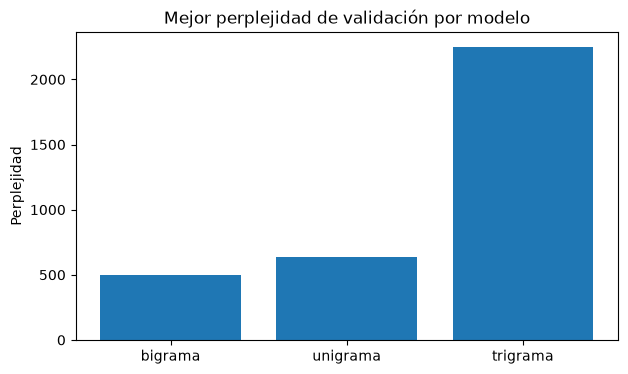

Mejor configuración en validación: bigrama con k=0.001


In [93]:
plt.figure(figsize=(7, 4))
plt.bar(resultados_perplejidad['Modelo'], resultados_perplejidad['Perplejidad validación'])
plt.title('Mejor perplejidad de validación por modelo')
plt.ylabel('Perplejidad')
plt.show()

ganador = resultados_perplejidad.iloc[0]
mejor_modelo_general = ganador['Modelo']
k_suavizado = float(ganador['k'])

print(f"Mejor configuración en validación: {mejor_modelo_general} con k={k_suavizado:g}")


**¿Cuál obtiene menor perplejidad? ¿Coincide con lo esperado según el trade-off de contexto vs. dispersión visto en clase?**

El modelo que obtiene la menor perplejidad en validación es el bigrama con k=0.001, con una perplejidad de aproximadamente 499.50. El resultado es consistente con el trade-off entre contexto y dispersión. El bigrama aprovecha una palabra de contexto y, al mismo tiempo, tiene muchas menos combinaciones posibles que un trigrama. El trigrama utiliza más contexto, pero también sufre una mayor dispersión de datos porque muchas combinaciones de tres palabras aparecen con muy poca frecuencia o no aparecen en el entrenamiento.

In [94]:
valores_k_bigramas = [0.01, 0.1, 0.5, 1.0, 2.0]

perplejidad_bigramas_k = pd.DataFrame({
    'k': valores_k_bigramas,
    'Perplejidad bigrama validación': [
        perplejidad(oraciones_val_modelo, 'bigrama', k=k)
        for k in valores_k_bigramas
    ]
})

mejor_k_bigrama = perplejidad_bigramas_k.loc[
    perplejidad_bigramas_k['Perplejidad bigrama validación'].idxmin(),
    'k'
]

perplejidad_bigramas_k

,k,Perplejidad bigrama validación
0,0.01,512.722032
1,0.10,828.353384
2,0.50,1546.134694
3,1.00,2139.849076
4,2.00,3002.462356


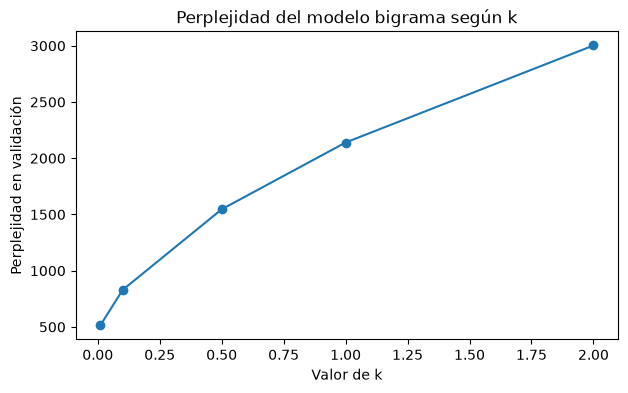

In [95]:
plt.figure(figsize=(7, 4))
plt.plot(perplejidad_bigramas_k['k'], perplejidad_bigramas_k['Perplejidad bigrama validación'], marker='o')
plt.title('Perplejidad del modelo bigrama según k')
plt.xlabel('Valor de k')
plt.ylabel('Perplejidad en validación')
plt.show()

**¿Cómo cambia la perplejidad del modelo de bigramas al aumentar k? ¿Por qué?**

La perplejidad del modelo de bigramas aumenta a medida que aumenta el valor de k. En los resultados obtenidos, pasó de ser 512.72 con k=0.01 a 3002.46 con k=2.00. Esto ocurre porque, al aumentar k, se asigna más probabilidad a los n-gramas que no fueron observados y, como consecuencia, se reduce la probabilidad que reciben los n-gramas frecuentes que sí aparecieron en el entrenamiento. En este caso, los valores pequeños de k producen un mejor resultado porque permiten dar algo de probabilidad a los n-gramas no vistos sin modificar demasiado las probabilidades de los n-gramas frecuentes.


In [96]:
modelo_final = mejor_modelo_general
k_final = k_suavizado

perplejidad_test_final = perplejidad(oraciones_test_modelo, modelo_final, k=k_final)

print(f"Modelo final seleccionado (según validación): {modelo_final}")
print(f"k final seleccionado: {k_final:g}")
print(f"Perplejidad final en prueba: {perplejidad_test_final:.4f}")


Modelo final seleccionado (según validación): bigrama
k final seleccionado: 0.001
Perplejidad final en prueba: 478.0274


---

### 5. Aplicación práctica: autocompletado

In [97]:
modelo_autocompletado = modelo_final
k_autocompletado = k_final


def tokenizar_fragmento(fragmento):
    tokens = word_tokenize(fragmento, language='spanish')
    return [token if token in vocabulario_train else UNK for token in tokens]


def es_candidato_valido(palabra):
    return palabra not in {'<s>', '</s>', UNK} and palabra.isalpha()


def prob_siguiente_palabra(palabra, contexto_tokens):
    modelo = modelo_autocompletado
    k = k_autocompletado

    if modelo == 'unigrama':
        return prob_unigrama_add_k(palabra, k)

    elif modelo == 'bigrama':
        contexto = contexto_tokens[-1] if contexto_tokens else '<s>'
        return prob_bigrama_add_k(contexto, palabra, k)

    elif modelo == 'trigrama':
        if len(contexto_tokens) >= 2:
            contexto_1, contexto_2 = contexto_tokens[-2], contexto_tokens[-1]
        elif len(contexto_tokens) == 1:
            contexto_1, contexto_2 = '<s>', contexto_tokens[-1]
        else:
            contexto_1, contexto_2 = '<s>', '<s>'
        return prob_trigrama_add_k(contexto_1, contexto_2, palabra, k)

    else:
        raise ValueError("modelo debe ser 'unigrama', 'bigrama' o 'trigrama'")


def autocompletar(fragmento, top_n=5):
    contexto_tokens = tokenizar_fragmento(fragmento)
    candidatos = [palabra for palabra in vocabulario_modelo if es_candidato_valido(palabra)]

    resultados = [
        (palabra, prob_siguiente_palabra(palabra, contexto_tokens))
        for palabra in candidatos
    ]

    resultados = sorted(resultados, key=lambda x: (-x[1], x[0]))[:top_n]

    return pd.DataFrame(resultados, columns=['Sugerencia', 'Probabilidad'])


In [98]:
def obtener_fragmentos_de_prueba(oraciones, cantidad=5, palabras_fragmento=4, semilla=42):
    fragmentos_validos = []

    for oracion in oraciones:
        tokens = [t for t in oracion if t not in {'<s>', '</s>'}]

        if len(tokens) <= palabras_fragmento:
            continue

        fragmento = ' '.join(tokens[:palabras_fragmento])
        fragmentos_validos.append(fragmento)

    random.seed(semilla)

    if len(fragmentos_validos) <= cantidad:
        return fragmentos_validos

    return random.sample(fragmentos_validos, cantidad)


fragmentos_prueba = obtener_fragmentos_de_prueba(oraciones_test)
fragmentos_prueba


['-¿Tan malas obras te',
 'Niéguenme , asimesmo ,',
 'Y así , se',
 'AMADÍS DE GAULA A',
 'Entonces sí que andaban']

In [99]:
for fragmento in fragmentos_prueba:
    print(f"Fragmento: {fragmento}")
    display(autocompletar(fragmento, top_n=5))
    print()

Fragmento: -¿Tan malas obras te


,Sugerencia,Probabilidad
0,he,0.053821
1,ha,0.038684
2,lo,0.021866
3,digo,0.020184
4,hago,0.013456



Fragmento: Niéguenme , asimesmo ,


,Sugerencia,Probabilidad
0,y,0.153729
1,que,0.105952
2,con,0.024804
3,como,0.024369
4,porque,0.023904



Fragmento: Y así , se


,Sugerencia,Probabilidad
0,le,0.070874
1,me,0.035700
2,ha,0.033862
3,había,0.023100
4,lo,0.022312



Fragmento: AMADÍS DE GAULA A


,Sugerencia,Probabilidad
0,lo,0.445866
1,esto,0.047947
2,este,0.033564
3,cuyas,0.028770
4,esta,0.028770



Fragmento: Entonces sí que andaban


,Sugerencia,Probabilidad
0,buscando,0.045910
1,con,0.045910
2,por,0.045910
3,alborotados,0.022967
4,allí,0.022967


**Pruebe la función con al menos 5 fragmentos distintos tomados de oraciones reales del conjunto de prueba y comente si las sugerencias son razonables.**

Las sugerencias obtenidas son razonables en términos generales, aunque no todas corresponden necesariamente a la continuación exacta de la oración original. En general, si parece que el modelo logra generar continuaciones a fragmentos posibles, pero su calidad está limitada por el uso de un modelo de bigramas, que solamente considera una palabra de contexto.


**Como el corpus es una novela del siglo XVII, es normal que las sugerencias reflejen un vocabulario y estilo distintos al español actual; coméntelo si lo observa.**

En general las sugerencias de estos 5 fragmentos parecen que reflejan el español actual. Por ejemplo, en el fragmento «AMADÍS DE GAULA A» aparece la sugerencia «cuyas», que aunque sigue siendo correcta en el español actual, también encaja con el estilo y el vocabulario del texto de Cervantes. En general, el modelo refleja principalmente los patrones y el vocabulario presentes en el corpus histórico pero es posible que si se proporcionan otros fragmentos, puden haber sugerencias que reflejen de forma mas cercana el estilo de escritura de Cervantes.